In [3]:
import re
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap, Normalize
from matplotlib.cm import ScalarMappable

from scipy.stats import spearmanr, pearsonr, ttest_ind, mannwhitneyu
from statsmodels.stats.multitest import multipletests

plt.style.use("ggplot")

## Validation ccRCC

In [12]:
ann_data = sc.read_h5ad('../data/validation_data/rnaseq/PD45816_6800STDY12499506_I2.annotated.h5ad')
tca_status = pd.read_csv("../data/validation_data/spatial/tca_count_validation.csv", index_col=0)
flux_data = pd.read_csv("../data/validation_data/spatial/flux_mean_validation.csv", index_col=0)

In [15]:
spot_ann = pd.DataFrame(index=ann_data.obs_names, 
                        data={"annotation": ann_data.obs['region_annotation']})

biomass_syn_flux = flux_data["Biomass"]

print(tca_status.shape, spot_ann.shape)
tca_status["region_annotation"] = spot_ann.loc[tca_status.index, "annotation"]
tca_status["biomass_syn_flux"] = biomass_syn_flux.loc[tca_status.index]
print(tca_status.shape)

(1777, 8) (1777, 1)
(1777, 10)


In [16]:
# filtre out unknown region (NA)
print("Before filter:", tca_status.shape)
tca_status = tca_status[tca_status["region_annotation"] != "NA"]
print("After filter:", tca_status.shape)

Before filter: (1777, 10)
After filter: (1705, 10)


biomass_syn_flux - t-stat: 54.27, p = 6.9e-307
nc_propensity - t-stat: 39.61, p = 7.3e-178
nc_flux_intensity - t-stat: 96.30, p < 1e-308


C:\Users\LL331070\AppData\Local\Temp\ipykernel_38304\2656298177.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\LL331070\AppData\Local\Temp\ipykernel_38304\2656298177.py:36: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
C:\Users\LL331070\AppData\Local\Temp\ipykernel_38304\2656298177.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\LL331070\AppData\Local\Temp\ipykernel_38304\2656298177.py:36: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
C:\U

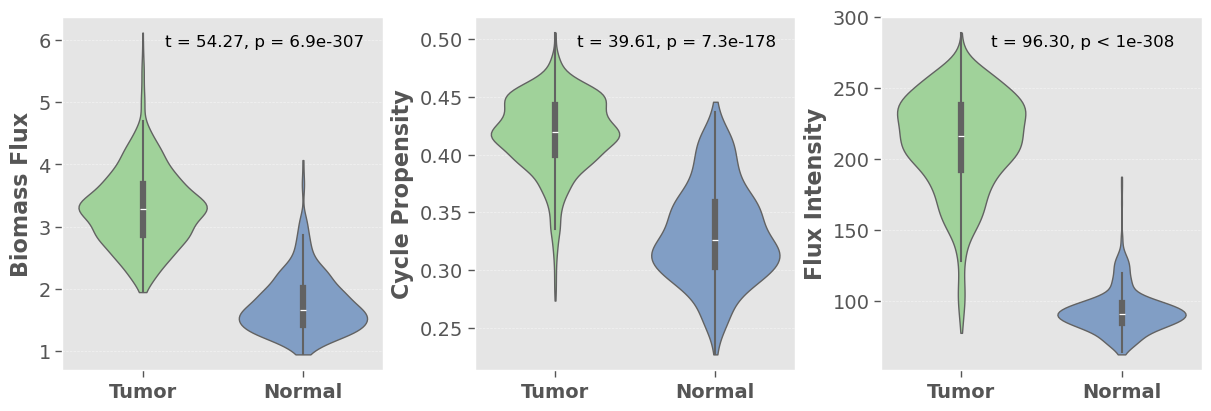

In [22]:
# Subito dopo aver creato tca_status
tca_status = tca_status.copy()

tca_status.loc[:, "region_annotation"] = tca_status["region_annotation"].replace({
    "Renal parenchyma": "Normal"
})
order = ["Tumor", "Normal"]

metrics = [
    ("biomass_syn_flux", "Biomass Flux"),
    ("nc_propensity", "Cycle Propensity"),
    ("nc_flux_intensity", "Flux Intensity"),
]

SAFE_MIN_P = 1e-308
def fmt_p(p):
    return "p < 1e-308" if np.isfinite(p) and p < SAFE_MIN_P else f"p = {p:.1e}"

sns.set_context("paper")
fig, axes = plt.subplots(1, 3, figsize=(12, 4), constrained_layout=True)

for ax, (col, ylab) in zip(axes, metrics):
    # Subset e dropna
    df_plot = tca_status.loc[
        tca_status["region_annotation"].isin(order), 
        ["region_annotation", col]
    ].dropna()

    # Welch’s t-test
    x1 = df_plot.loc[df_plot["region_annotation"] == order[0], col].values
    x2 = df_plot.loc[df_plot["region_annotation"] == order[1], col].values
    t_stat, p_val = ttest_ind(x1, x2, equal_var=False)
    print(f"{col} - t-stat: {t_stat:.2f}, {fmt_p(p_val)}")

    # Violin plot 
    sns.violinplot(
        data=df_plot,
        x="region_annotation",
        y=col,
        order=order,
        ax=ax,
        inner="box",
        cut=0,
        scale="width",
        palette={"Tumor": "#99db91", "Normal": "#769dd0"},
    )

    # Labeling
    ax.set_xlabel(None)
    ax.set_ylabel(ylab, fontsize=16, fontweight="bold")
    ax.tick_params(axis="y", labelsize=14)
    ax.tick_params(axis="x", labelsize=14)
    for tick in ax.get_xticklabels():
        tick.set_fontweight("bold")
    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)

    # statistics annotation
    ax.text(
        0.63, 0.95, f"t = {t_stat:.2f}, {fmt_p(p_val)}",
        transform=ax.transAxes, ha="center", va="top", fontsize=12
    )

plt.savefig("../data/validation_data/spatial/plots/tca_metrics_tumor_vs_parenchyma.png",
            dpi=600, bbox_inches='tight')
plt.show()

## Tumor heterogeneity


In [2]:
cell_notation = pd.read_csv("../data/features_label/metadata/Cell_lines_annotations.csv", index_col=0)

tca_status = pd.read_csv("../data/features_label/tca_status_medium.csv", index_col=0)
tca_status.columns

Index(['TCA canonical', 'TCA non canonical', 'both active',
       'biomass mean TCA no canonical', 'biomass mena both active',
       'activity TCA canonical', 'activity TCA non canonical', 'NC/C',
       'Valid_sample', 'Type', 'activity SUM NC', 'activity SUM C'],
      dtype='object')

In [3]:
nc_state = tca_status.loc[:, ['TCA non canonical', 'activity TCA non canonical']].copy()
nc_state.rename(columns={'TCA non canonical': 'propensity',
                       'activity TCA non canonical': 'flux intensity'}, inplace=True)

nc_state["Type"] = nc_state.index.str.split("_", n=1).str[1].str.replace("_", " ")
nc_state.head()

,propensity,flux intensity,Type
22RV1_PROSTATE,0.3547,14.794442,PROSTATE
2313287_STOMACH,0.3046,13.072795,STOMACH
5637_URINARY_TRACT,0.5422,12.879744,URINARY TRACT
697_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,0.5623,10.430198,HAEMATOPOIETIC AND LYMPHOID TISSUE
769P_KIDNEY,0.4553,17.514556,KIDNEY


In [4]:
nc_state = nc_state.merge(cell_notation, left_index=True, right_index=True)
mask = nc_state["Type"] == "HAEMATOPOIETIC AND LYMPHOID TISSUE"
nc_state.loc[mask, "Type"] = nc_state.loc[mask, "Histology"].str.split("_").str[0]
nc_state['Type'] = nc_state['Type'].str.upper()
nc_state = nc_state[["propensity", "flux intensity", "Type"]]
nc_state.head()

,propensity,flux intensity,Type
22RV1_PROSTATE,0.3547,14.794442,PROSTATE
2313287_STOMACH,0.3046,13.072795,STOMACH
5637_URINARY_TRACT,0.5422,12.879744,URINARY TRACT
697_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,0.5623,10.430198,LYMPHOID
769P_KIDNEY,0.4553,17.514556,KIDNEY


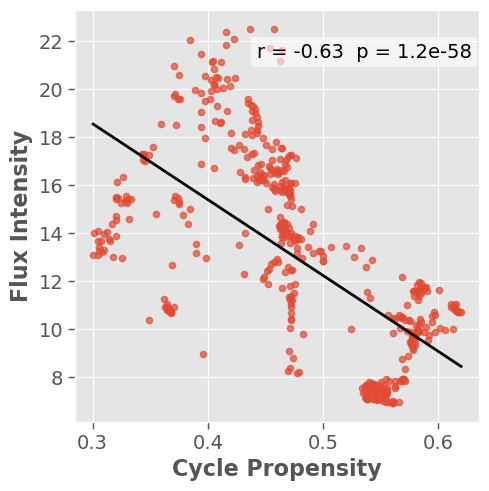

In [5]:
def _pad(lo, hi, frac=0.05):
    span = hi - lo if hi > lo else 1.0
    pad = frac * span
    return lo - pad, hi + pad

dfp = nc_state[['propensity', 'flux intensity']].dropna().copy()
USE_ABS_Y = False  
if USE_ABS_Y:
    dfp['flux intensity'] = dfp['flux intensity'].abs()

x = dfp['propensity'].to_numpy()
y = dfp['flux intensity'].to_numpy()

if len(dfp) > 1 and np.std(x) > 0 and np.std(y) > 0:
    corr, pval = pearsonr(x, y)
else:
    corr, pval = np.nan, np.nan

sns.set_context("paper")
plt.figure(figsize=(5, 5))
ax = sns.regplot(
    x='propensity',
    y='flux intensity',
    data=dfp,
    ci=None,
    scatter_kws=dict(s=20, alpha=0.7),
    line_kws=dict(lw=2, color='black')
)

ax.set_xlim(*_pad(dfp['propensity'].min(), dfp['propensity'].max()))
ax.set_ylim(*_pad(dfp['flux intensity'].min(), dfp['flux intensity'].max()))

ax.set_xlabel('Cycle Propensity', fontsize=16, fontweight='bold')
ax.set_ylabel('Flux Intensity', fontsize=16, fontweight='bold')
ax.tick_params(axis="both", labelsize=14)

ax.text(
    0.45, 0.92,
    (f"r = {corr:.2f}  p = {pval:.1e}") if np.isfinite(corr) else "r = n/a  p = n/a",
    transform=ax.transAxes,
    fontsize=14,
    va='top', ha='left',
    bbox=dict(facecolor='white', alpha=0.6, edgecolor='none')
)

plt.tight_layout()
plt.savefig("../data/validation_data/ccle/output/plots/corr_propensity_flux_single.png", dpi=600, bbox_inches='tight')
plt.show()


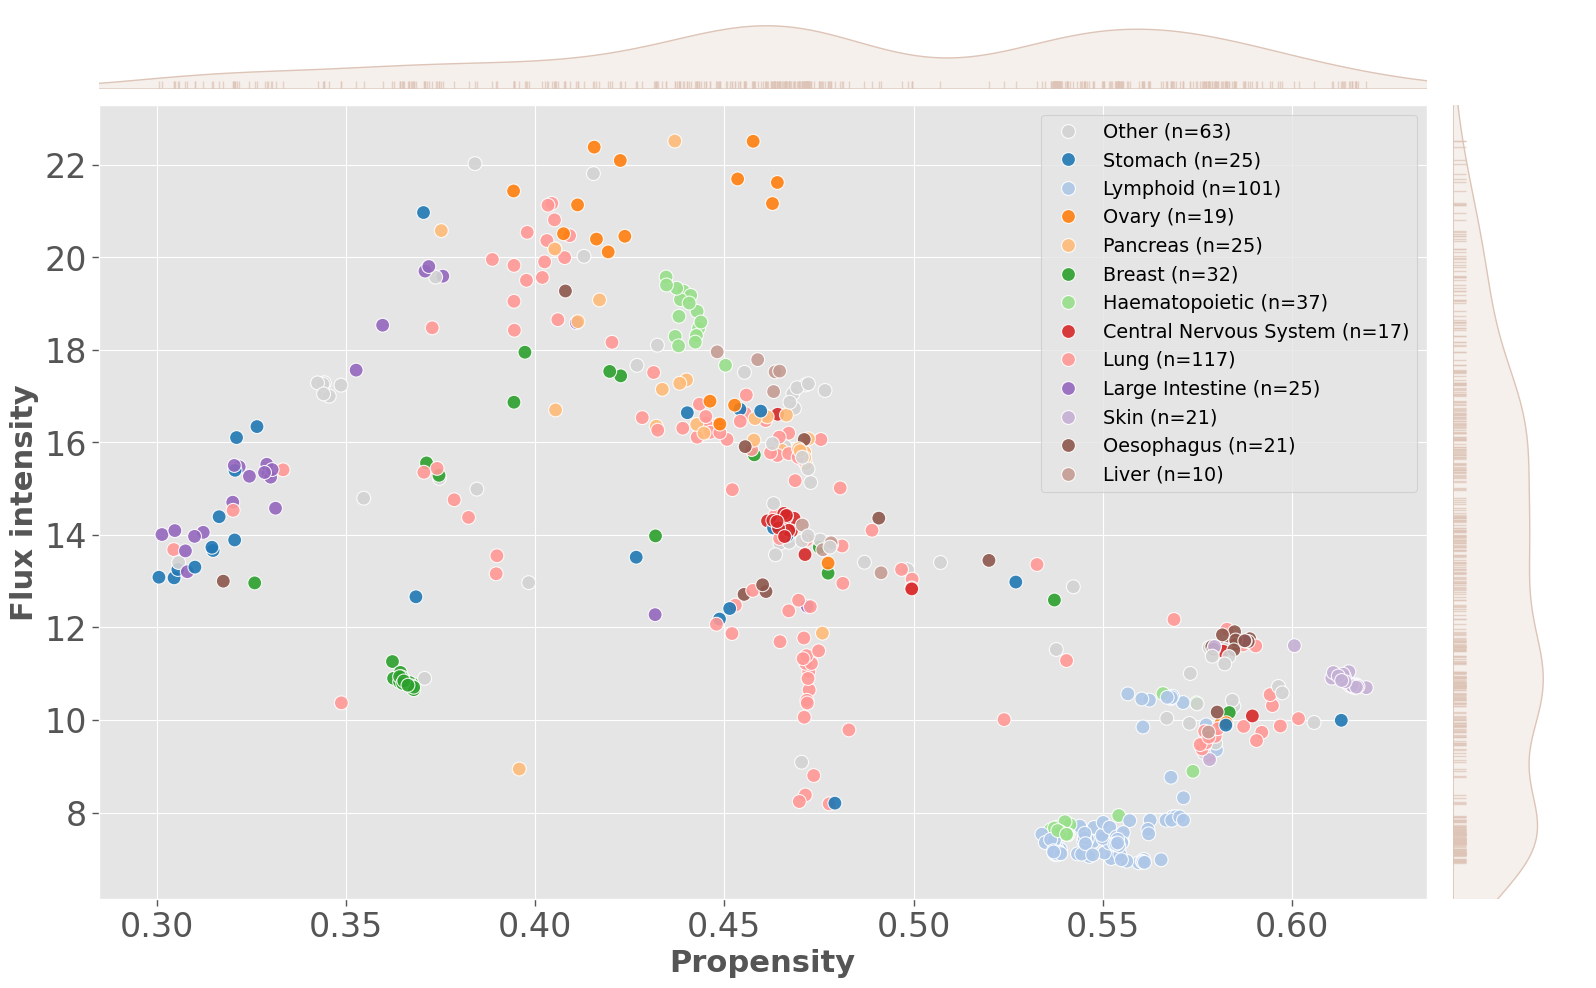

In [6]:
min_count = 10

counts = nc_state['Type'].value_counts()
small_types = counts[counts < min_count].index
nc_state['Type_agg'] = nc_state['Type'].where(
    ~nc_state['Type'].isin(small_types),
    other='Other'
)

# Count occurrences of each type for legend
type_counts = nc_state['Type_agg'].value_counts()

major_types = [t for t in nc_state['Type_agg'].unique() if t != 'Other']
base_palette = sns.color_palette("tab20", n_colors=len(major_types))
palette = dict(zip(major_types, base_palette))
palette['Other'] = 'lightgrey'

sns.set_context("paper", font_scale=1.2)
fig, ax = plt.subplots(figsize=(16, 10))

sns.scatterplot(
    data=nc_state,
    x="propensity",
    y="flux intensity",
    hue="Type_agg",
    palette=palette,
    alpha=0.9,
    s=100,
    edgecolor='w',
    ax=ax
)

# include the counts in the legend labels
handles, labels = ax.get_legend_handles_labels()

new_labels = []
for label in labels:
    label_clean = label.title()

    if label_clean in type_counts.index:
        new_labels.append(f"{label_clean} (n={type_counts[label_clean]})")
    elif label in type_counts.index:
        new_labels.append(f"{label.title()} (n={type_counts[label]})")
    else:
        new_labels.append(label_clean)

ax.legend(handles, new_labels, loc='upper right', fontsize='large', frameon=True)


ax.set_xlabel("Propensity", fontsize=22, fontweight='bold')
ax.set_ylabel("Flux intensity", fontsize=22, fontweight='bold')
ax.tick_params(axis='both', which='major', labelsize=24)

xlim = ax.get_xlim()
ylim = ax.get_ylim()

# create inset axes for rug and kde plots
ax_rug_kde_x = ax.inset_axes([0, 1.02, 1, 0.1], sharex=ax)
ax_rug_kde_y = ax.inset_axes([1.02, 0, 0.1, 1], sharey=ax)

# Remove unnecessary visual elements from the axes
for rug_ax in [ax_rug_kde_x, ax_rug_kde_y]:
    for spine in rug_ax.spines.values():
        spine.set_visible(False)
    rug_ax.set_facecolor('white')
    rug_ax.tick_params(axis='both', which='both', 
                       bottom=False, top=False, left=False, right=False,
                       labelbottom=False, labelleft=False)


kde_color = "#DDC4B7AC"

# add the rug plots
rug_x = sns.rugplot(data=nc_state, x='propensity', ax=ax_rug_kde_x, color=kde_color, height=0.1, lw=1)  # ridotto da 0.3 a 0.1
rug_y = sns.rugplot(data=nc_state, y='flux intensity', ax=ax_rug_kde_y, color=kde_color, height=0.1, lw=1)  # ridotto da 0.3 a 0.1

# add the KDE plots without fill
kde_x = sns.kdeplot(data=nc_state, x='propensity', ax=ax_rug_kde_x, color=kde_color, fill=True, lw=1)
kde_y = sns.kdeplot(data=nc_state, y='flux intensity', ax=ax_rug_kde_y, color=kde_color, fill=True, lw=1)

# Fill the rug plots
ax_rug_kde_x.collections[0].set_facecolor(kde_color)
ax_rug_kde_x.collections[0].set_edgecolor(kde_color)
ax_rug_kde_x.collections[0].set_alpha(0.7)

ax_rug_kde_y.collections[0].set_facecolor(kde_color)
ax_rug_kde_y.collections[0].set_edgecolor(kde_color)
ax_rug_kde_y.collections[0].set_alpha(0.7)

# Remove margins between KDE and main axes
ax_rug_kde_x.margins(x=0)
ax_rug_kde_y.margins(y=0)

# Set y-limits for KDE to make them more visible
ax_rug_kde_x.set_ylim(bottom=0)
ax_rug_kde_y.set_xlim(left=0)

# Restore original scatter plot limits to maintain proportions
ax.set_xlim(xlim)
ax.set_ylim(ylim)
plt.savefig("../data/validation_data/ccle/output/plots/non_canonical_state_scatter_rug_kde.png", dpi=600)
plt.tight_layout()
plt.show()

## Rerouting

In [49]:
flux_active = pd.read_csv("../data/validation_data/ccle/input/mean_flux_active_samp.csv")
tca_metrics_ccle = pd.read_csv("../data/dependency_analysis/input_data/tca_metrics.csv", index_col=0)

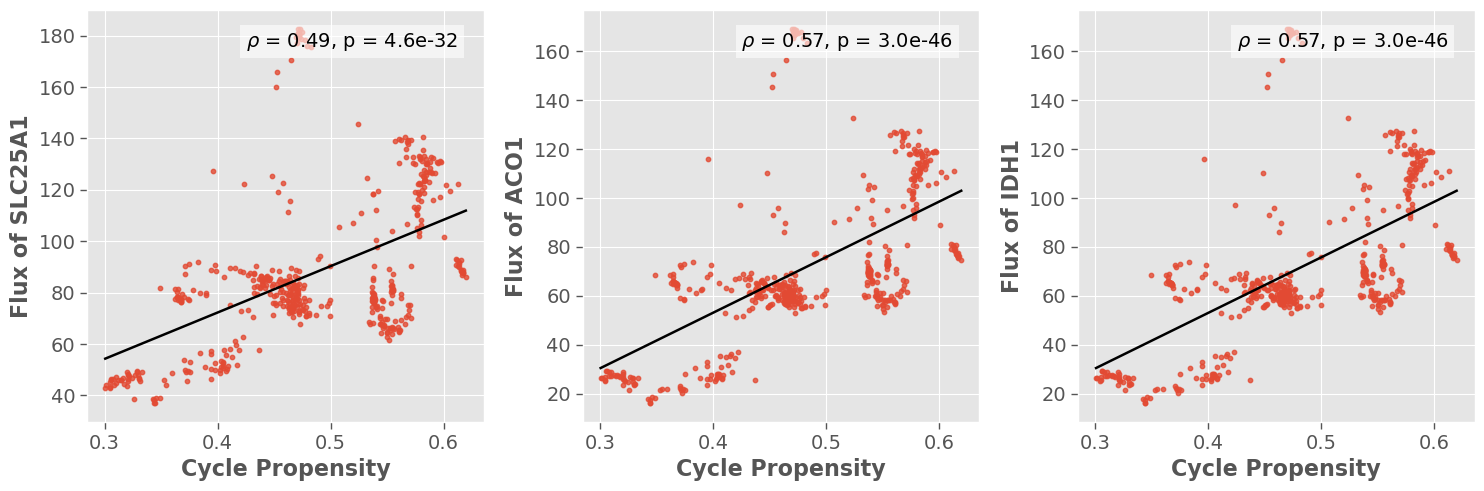

In [53]:
reactions = {
    "HMR_4964": "SLC25A1",
    "ACONT": "ACO1",
    "ICDHyr": "IDH1"
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharex=True)

for ax, (reaction_id, reaction_label) in zip(axes, reactions.items()):
    subset = flux_active.loc[flux_active['reaction'] == reaction_id, ['cell_line', 'mean_flux']].copy()
    subset = subset.set_index('cell_line')
    tca_idx = tca_metrics_ccle['Propensity']
    subset = subset.join(tca_idx.rename("propensity"), how='inner')

    corr, pval = pearsonr(subset['propensity'], subset['mean_flux'])

    sns.regplot(
        x='propensity',
        y='mean_flux',
        data=subset,
        ci=None,
        scatter_kws={'s': 10},
        line_kws={'color': 'black'},
        ax=ax
    )

    ax.set_xlabel("Cycle Propensity", fontsize=16, fontweight='bold')
    ax.set_ylabel(f"Flux of {reaction_label}", fontsize=16, fontweight='bold')
    ax.tick_params(axis='both', labelsize=14)

    ax.text(0.4, 0.95, f"$\\rho$ = {corr:.2f}, p = {pval:.1e}",
            transform=ax.transAxes,
            fontsize=14,
            verticalalignment='top',
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none')
)

plt.tight_layout()
plt.savefig("../data/validation_data/ccle/output/plots/corr_propensity_flux_reactions.png", dpi=600, bbox_inches='tight')
plt.show()


## Warburg

In [57]:
flux = pd.read_csv("../data/validation_data/ccle/input/cbs_mean_magic.csv", index_col=0)
tca_metrics_ccle = pd.read_csv("../data/dependency_analysis/input_data/tca_metrics.csv", index_col=0)
trasc = sc.read_h5ad("../data/features_label/raw_X/rna_seq_total")
trasc_df = pd.DataFrame(trasc.X, index=trasc.obs_names, columns=trasc.var_names)
flux.columns

Index(['EX_lac__L_e', 'EX_glc__D_e', 'EX_glu__L_e', 'EX_gln__L_e',
       'EX_asp__L_e', 'EX_co2_e', 'EX_h_e', 'EX_h2o_e', 'EX_pi_e', 'EX_nh4_e',
       ...
       't_Lcystin_glu__L', 't_Lcystin_leu__L', 't_Lcystin_ser__L', 'CSNATr',
       'CRNCARtm', 'CSNATm', 'ACS', 'ACt2m', 'PyrODC', 'Incompox_Pyr'],
      dtype='object', length=469)

In [58]:
tca_metrics_ccle["Lac"] = flux["EX_lac__L_e"]
tca_metrics_ccle["Glc"] = flux["EX_glc__D_e"]
tca_metrics_ccle["O2"] = flux["EX_o2_e"]
tca_metrics_ccle["Lac/Glc"] = flux["EX_lac__L_e"] / - flux["EX_glc__D_e"]

df = tca_metrics_ccle.copy()
o2_col = "O2"

pairs = [
    ("Propensity", "Lac", "Lactate export"),
    ("Propensity", "Lac/Glc", "Lac/Glc Ratio"),
    ("Propensity", o2_col, "Oxygen consump."),

]
pairs = [(x, y, label) for x, y, label in pairs if (x is not None and y in df.columns)]

if len(pairs) == 0:
    raise ValueError("Nessuna coppia valida trovata. Controlla i nomi colonna del dataframe.")

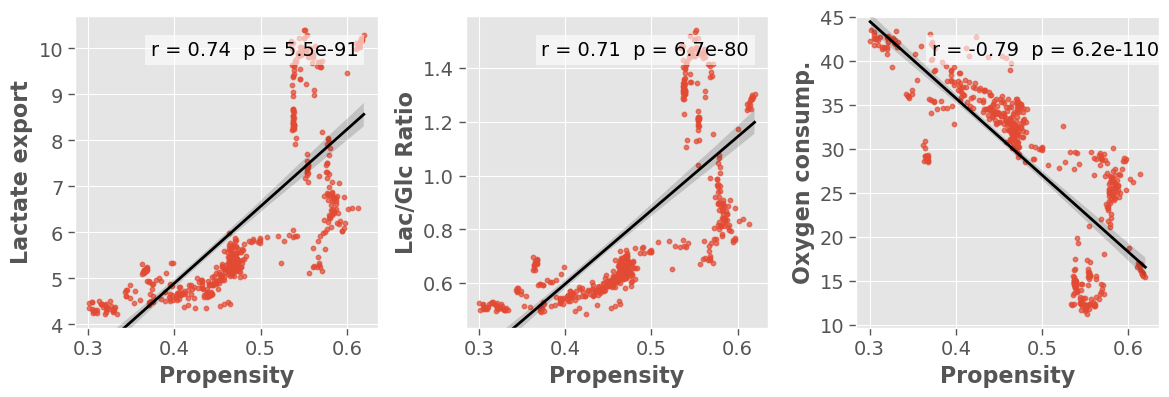

In [59]:
def _pad(lo, hi, frac=0.05):
    span = hi - lo if hi > lo else 1.0
    pad = frac * span
    return lo - pad, hi + pad

fig, axes = plt.subplots(1, len(pairs), figsize=(12, 4), squeeze=False)
axes = axes.ravel()

for ax, (xcol, ycol, ylabel) in zip(axes, pairs):
    dfp = df[[xcol, ycol]].dropna().copy()
    # Usa il valore assoluto di y
    dfp[ycol] = dfp[ycol].abs()
    
    x, y = dfp[xcol].to_numpy(), dfp[ycol].to_numpy()

    if len(dfp) > 1 and np.std(x) > 0 and np.std(y) > 0:
        r, p = pearsonr(x, y)
    else:
        r, p = np.nan, np.nan

    sns.regplot(
        x=xcol, y=ycol, data=dfp, ax=ax,
        scatter_kws=dict(s=10, alpha=0.7),
        line_kws=dict(lw=2, color='black')
    )

    ax.set_xlim(*_pad(dfp[xcol].min(), dfp[xcol].max()))
    ax.set_ylim(*_pad(dfp[ycol].min(), dfp[ycol].max()))
    ax.set_xlabel("Propensity", fontsize=16, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=16, fontweight='bold')
    ax.tick_params(axis="both", labelsize=14)

    ax.text(
        0.25, 0.92,
        f"r = {r:.2f}  p = {p:.1e}" if np.isfinite(r) else "r = n/a  p = n/a",
        transform=ax.transAxes,
        fontsize=14,
        va='top', ha='left',
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none')
    )

fig.tight_layout()
fig.savefig("../data/validation_data/ccle/output/plots/corr_propensity_lac_o2_lacglc_abs.png",
            dpi=600, bbox_inches='tight')
plt.show()


## ORA

In [3]:
bp_path = "../data/ora_result/enrichment_bp_filtered.csv"
hm_path = "../data/ora_result/enrichment_hallmark.csv"
kg_path = "../data/ora_result/enrichment_kegg.csv"

out_png = "../data/ora_result/plots/ora_combined_enrichment.png"

In [4]:
def clean_go_term(s: str) -> str:
    s = str(s)
    if s.startswith("GO:"):
        parts = s.split(" ", 1)
        s = parts[1].strip() if len(parts) == 2 else s.strip()
    else:
        s = s.strip()
    repl = {
        "regulation": "reg.", "Regulation": "Reg.",
        "negative": "Neg.", "Negative": "Neg.",
        "positive": "Pos.", "Positive": "Pos.",
        "process": "proc.", "Process": "Proc.",
        #"development": "dev.", "Development": "Dev."
    }
    for k, v in repl.items():
        s = s.replace(k, v)
    return s.strip()

def clean_hallmark_name(s: str) -> str:
    s = str(s).strip().strip('"').strip("'")
    if s.upper().startswith("HALLMARK"):
        s = s[len("HALLMARK"):].lstrip("_").strip()
    return s.replace("_", " ").title()

def parse_kegg_term(s: str):
    s = str(s).strip().strip('"').strip("'")
    if s.lower().startswith("path:"):
        s = s.split(":", 1)[1].strip()
    m = re.match(r"^(?P<kid>[a-zA-Z]{2,3}\d{5})\s+(?P<name>.+)$", s)
    if m:
        return m.group("kid").strip(), m.group("name").strip()
    return "", s

# Load GO
go = pd.read_csv(bp_path)
go = go.rename(columns={
    "Enrichment FDR": "FDR",
    "Fold Enrichment": "FE",
    "nGenes": "n_genes",
    "Pathway": "term",
    "GO_ID": "go_id"
})
go["term_label"] = go["term"].apply(clean_go_term)
go["source"] = "GO:BP"

# Load Hallmark
hm_cols = ["FDR", "n_genes", "term_size", "FE", "term", "url", "genes"]
hm_try = pd.read_csv(hm_path, header=None, names=hm_cols)
if any(isinstance(x, str) and ("FDR" in x or "Path:" in x) for x in hm_try.iloc[0].values):
    hm = hm_try.drop(index=0).reset_index(drop=True)
else:
    hm = hm_try.copy()
for c in ["FDR", "n_genes", "FE"]:
    hm[c] = pd.to_numeric(hm[c], errors="coerce")
hm["term_label"] = hm["term"].apply(clean_hallmark_name)
hm["source"] = "Hallmark"

# Load KEGG
kg_cols = ["FDR", "n_genes", "term_size", "FE", "term", "url", "genes"]
kg_try = pd.read_csv(kg_path, header=None, names=kg_cols)
if any(isinstance(x, str) and ("FDR" in x or "Path:" in x) for x in kg_try.iloc[0].values):
    kg = kg_try.drop(index=0).reset_index(drop=True)
else:
    kg = kg_try.copy()
for c in ["FDR", "n_genes", "FE"]:
    kg[c] = pd.to_numeric(kg[c], errors="coerce")
parsed = kg["term"].apply(parse_kegg_term)
kg["kegg_id"] = parsed.apply(lambda x: x[0])
kg["term_label"] = parsed.apply(lambda x: x[1])
kg["source"] = "KEGG"

# Combine
all_df = pd.concat([go, hm, kg], ignore_index=True)
all_df["FDR"] = pd.to_numeric(all_df["FDR"], errors="coerce").clip(lower=1e-300)
all_df["n_genes"] = pd.to_numeric(all_df["n_genes"], errors="coerce")
all_df["FE"] = pd.to_numeric(all_df["FE"], errors="coerce")
all_df["neglog10FDR"] = -np.log10(all_df["FDR"])

fdr_thr = 0.05
all_df = all_df[all_df["FDR"] < fdr_thr].copy()

all_df = all_df.sort_values("neglog10FDR", ascending=True).reset_index(drop=True)
print(f"Total enriched terms: {all_df.shape[0]}")

Total enriched terms: 50


C:\Users\LL331070\AppData\Local\Temp\ipykernel_38304\2697429987.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


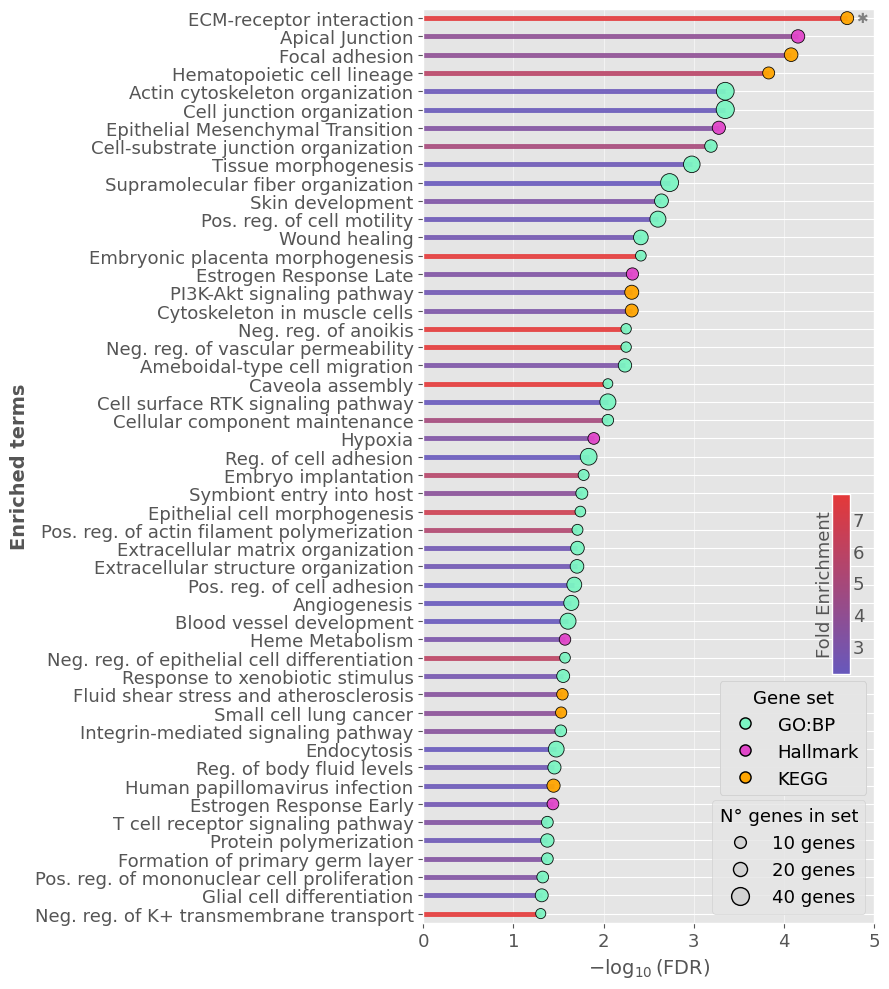

In [9]:
from matplotlib.ticker import MaxNLocator

y = np.arange(len(all_df))
fig, ax = plt.subplots(figsize=(9, 10))

# SIZE = n_genes
min_dot, max_dot = 50, 170
n = all_df["n_genes"].astype(float)
n_norm = (n - n.min()) / (n.max() - n.min() + 1e-9)
sizes = min_dot + n_norm * (max_dot - min_dot)

# X = -log10(FDR)
x_vals = all_df["neglog10FDR"].values

# FE (line color)
fe_raw = all_df["FE"].astype(float)
fe = fe_raw.fillna(fe_raw.median())
vmin, vmax = np.percentile(fe, [10, 90])
if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
    vmin, vmax = fe.min(), fe.max()
    if vmin == vmax:
        vmin, vmax = vmin - 1e-6, vmax + 1e-6
fe_for_color = np.clip(fe, vmin, vmax)
cmap = LinearSegmentedColormap.from_list("blue_red", ["#6758bc", "#e43838"])
norm = Normalize(vmin=vmin, vmax=vmax, clip=True)

# Cap su X e marcatura con asterisco
X_MAX, STAR_AT = 5.0, 4.7
mask_capped = x_vals > X_MAX
x_plot = np.where(mask_capped, STAR_AT, x_vals)

# Linee orizzontali
for i, (xv, fev) in enumerate(zip(x_plot, fe_for_color)):
    ax.hlines(y=i, xmin=0, xmax=xv, color=cmap(norm(fev)), linewidth=3.5, alpha=0.9, zorder=1)

# Scatter: faccia = sorgente
src_colors = {"GO:BP": "#7CF5C3", "Hallmark": "#E046C9", "KEGG": "#ffa500"}
face_cols = all_df["source"].map(src_colors).fillna("#BFBFBF")

sc = ax.scatter(
    x_plot, y,
    s=sizes, c=face_cols,
    edgecolor="k", linewidth=0.6, alpha=0.95, zorder=2
)

# Asterisco accanto ai punti cappati
for i, capped in enumerate(mask_capped):
    if capped:
        ax.text(STAR_AT + 0.1, i, "✱", va="center", ha="left", fontsize=10, zorder=3, color='grey')


y_labels = all_df["term_label"]
ax.set_yticks(y)
ax.set_yticklabels(y_labels, fontsize=13)
ax.set_ylim(-0.5, len(all_df) - 0.5)
ax.set_xlabel(r"$-\log_{10}(\mathrm{FDR})$", fontsize=14, fontweight='bold')
ax.set_ylabel("Enriched terms", fontsize=14, fontweight='bold')
ax.tick_params(axis="x", labelsize=13)
ax.set_xlim(0, X_MAX)

# Colorbar (Fold Enrichment)
cax = fig.add_axes([0.93, 0.32, 0.02, 0.18])
cb = plt.colorbar(ScalarMappable(norm=norm, cmap=cmap), cax=cax, orientation="vertical")
cb.ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
cb.set_label("Fold Enrichment", fontsize=13, labelpad=-35, y=0.5)
cb.ax.tick_params(labelsize=13, direction="in", pad=2)

# Legenda dimensione
size_ref = [10, 20, 40]
handles = []
for v in size_ref:
    s_pix = min_dot + ((v - n.min()) / (n.max() - n.min() + 1e-9)) * (max_dot - min_dot)
    s_pix = np.clip(s_pix, min_dot, max_dot)
    handles.append(Line2D([0], [0], marker='o', linestyle='',
                          markersize=np.sqrt(s_pix),
                          markerfacecolor='lightgray', markeredgecolor='k',
                          label=f"{v} genes"))
leg1 = ax.legend(handles=handles, title="N° genes in set",
                 loc="lower right", frameon=True,
                 fontsize=13, title_fontsize=13)
ax.add_artist(leg1)

# Legenda sorgente
src_handles = [
    Line2D([0], [0], marker='o', linestyle='',
           markerfacecolor=src_colors[s], markeredgecolor='k',
           label=s, markersize=8)
    for s in src_colors
]
leg2 = ax.legend(handles=src_handles, title="Gene set",
                 loc="lower center", frameon=True,
                 fontsize=13, title_fontsize=13,
                 bbox_to_anchor=(0.82, 0.13))
ax.add_artist(leg2)

# Stile finale
ax.grid(axis="x", alpha=0.5)
plt.tight_layout()
plt.savefig(out_png, dpi=600)
plt.show()

## DEPMAP

In [4]:
OUT_DIR = Path("../data/dependency_analysis/results/proliferation_corr/")
OUT_DIR.mkdir(parents=True, exist_ok=True)

In [5]:
res_flux = pd.read_csv(OUT_DIR / "sensitivity_analysis_flux_intensity.csv")
res_prop = pd.read_csv(OUT_DIR / "sensitivity_analysis_propensity.csv")
rX_prop = pd.read_csv("../data/dependency_analysis/results/proliferation_corr/residuals_X.csv", index_col=0)["Propensity_resid"]
rX_flux = pd.read_csv("../data/dependency_analysis/results/proliferation_corr/residuals_X.csv", index_col=0)["Flux_resid"]
dependency_df = pd.read_csv("../data/dependency_analysis/results/proliferation_corr/residuals_CERES.csv", index_col=0)

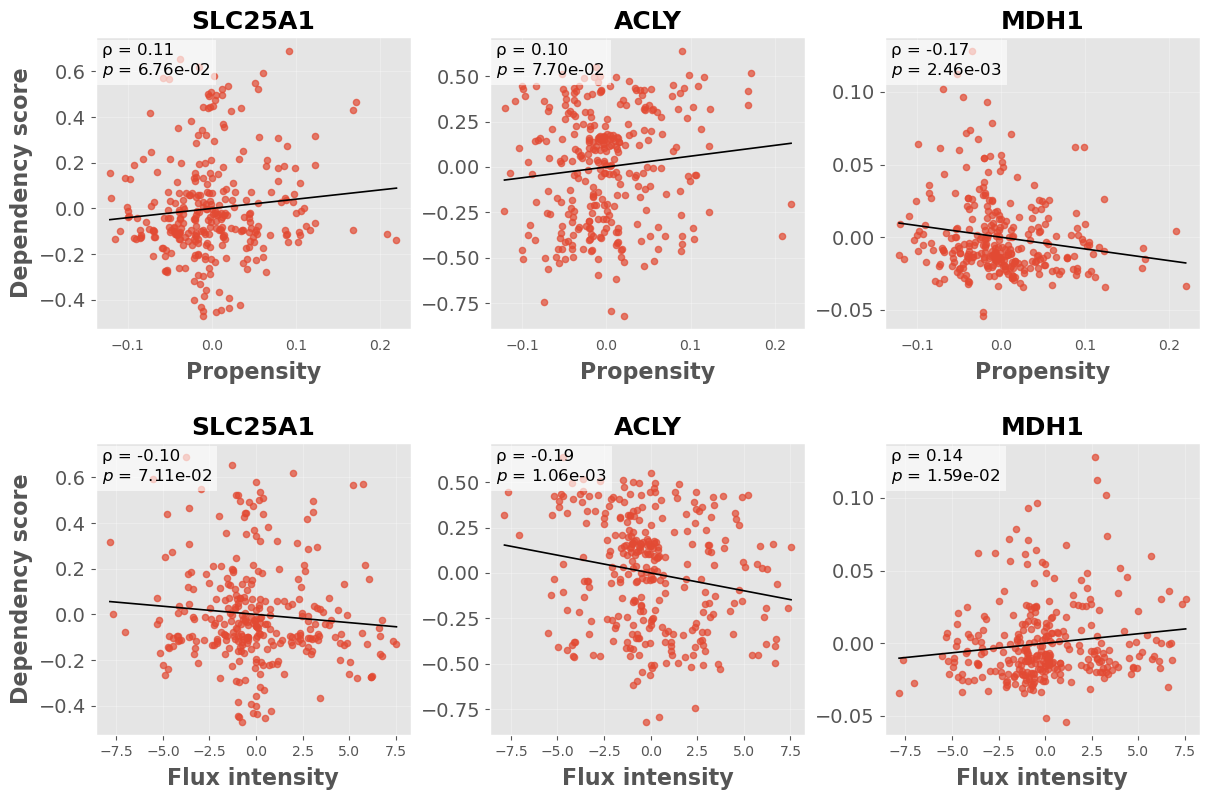

In [7]:
genes_cycle = ["SLC25A1", "ACLY", "MDH1"]

def _pad(lo, hi, frac=0.05):
    span = hi - lo if hi > lo else 1.0
    pad = frac * span
    return lo - pad, hi + pad

def plot_dep_scatter_grid(
    metrics,                 # [(xlab, resid_series), ...]
    dependency_df,           # CERES residuals (index=cell lines, columns=genes)
    genes,               
    outfile=None
):
    nrows = len(metrics)
    ncols = len(genes)

    fig, axes = plt.subplots(nrows, ncols, figsize=(12, 8), constrained_layout=True)
    fig.set_constrained_layout_pads(w_pad=0.05, h_pad=0.1, hspace=0.08, wspace=0.02)


    for i, (xlab, resid_series) in enumerate(metrics):
        resid = resid_series.rename(xlab)
        for j, gene in enumerate(genes):
            ax = axes[i, j]

            dfp = pd.concat([resid, dependency_df[gene]], axis=1, join="inner").dropna()
            dfp.columns = [xlab, "Dependency score"]

            rho, p = spearmanr(dfp[xlab], dfp["Dependency score"])

            sns.regplot(
                x=xlab, y="Dependency score", data=dfp, ax=ax,
                ci=None,
                scatter_kws=dict(s=20, alpha=0.7),
                line_kws=dict(lw=1.2, color="black")
            )

            ax.set_xlim(*_pad(dfp[xlab].min(), dfp[xlab].max()))
            ax.set_ylim(*_pad(dfp["Dependency score"].min(), dfp["Dependency score"].max()))

            ax.set_title(gene, fontweight='bold', fontsize=18)

            if j == 0:
                ax.set_ylabel("Dependency score", fontsize=16, fontweight='bold')
            else:
                ax.set_ylabel("")

            if i == nrows - 1:
                ax.set_xlabel(xlab, fontsize=16, fontweight='bold', labelpad=6)
                ax.xaxis.set_label_position('bottom')
                ax.tick_params(axis='x', labelbottom=True, bottom=True, labeltop=False, top=False)
            else:
                ax.set_xlabel("")
                ax.tick_params(axis='x', labelbottom=True, bottom=False, labeltop=False, top=False)

            ax.tick_params(axis='y', which='major', labelsize=14)
            ax.set_xlabel(xlab, fontsize=16, fontweight='bold', labelpad=6)

            ax.grid(True, alpha=0.3)

            ax.text(
                0.02, 0.98,
                f"ρ = {rho:.2f}\n$p$ = {p:.2e}",
                transform=ax.transAxes,
                fontsize=12,
                va='top', ha='left',
                bbox=dict(facecolor='white', alpha=0.65, edgecolor='none')
            )

    if outfile:
        fig.savefig(outfile, dpi=300)
    plt.show()

metrics_list = [
    ("Propensity", rX_prop),
    ("Flux intensity", rX_flux)
]

plot_dep_scatter_grid(
    metrics=metrics_list,
    dependency_df=dependency_df,
    genes=genes_cycle,
    outfile="../data/dependency_analysis/results/proliferation_corr/plots/cycle_genes_propensity_flux_grid.png"
)


C:\Users\LL331070\AppData\Local\Temp\ipykernel_41252\1626756406.py:64: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=[0, 0.02, 1, 0.98])


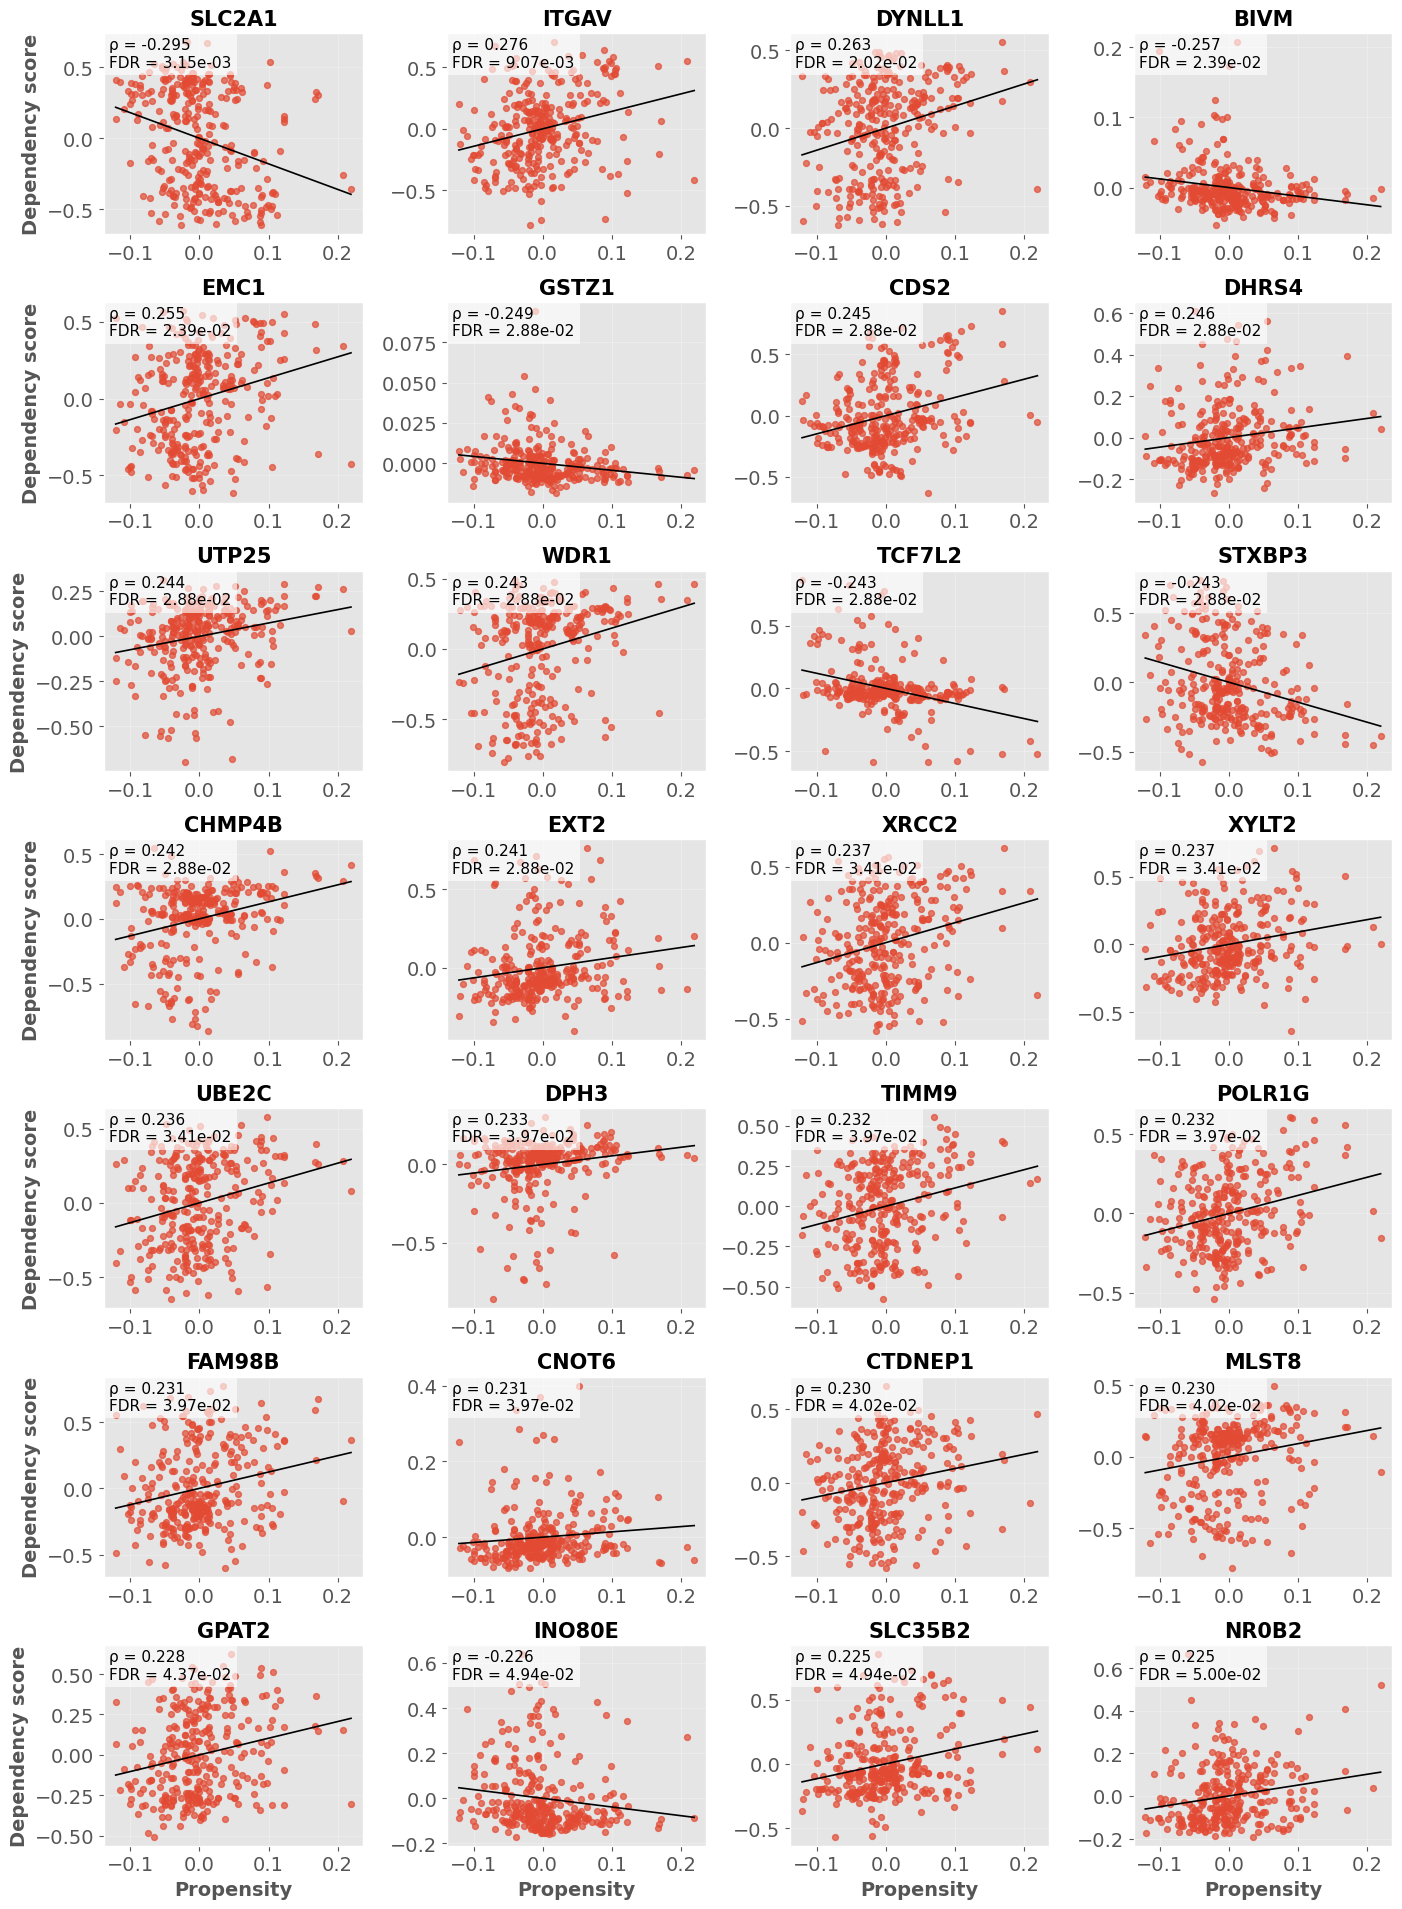

In [9]:
import math
top_prop = res_prop.head(28).copy()

def _pad(lo, hi, frac=0.05):
    span = hi - lo if hi > lo else 1.0
    pad = frac * span
    return lo - pad, hi + pad

n_genes = len(top_prop)
ncols = 4
nrows = math.ceil(n_genes / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 20), constrained_layout=True)
axes = axes.ravel()

for k, (_, row) in enumerate(top_prop.iterrows()):
    ax = axes[k]
    gene = row["Gene"]
    rho = row["rho"]
    p = row["p"]
    q = row.get("q", float("nan"))
    n = int(row.get("n", 0))

    dfp = pd.concat([rX_prop, dependency_df[gene]], axis=1, join="inner").dropna()
    dfp.columns = ["Propensity_resid", "Gene_value"]

    sns.regplot(
        x="Propensity_resid", y="Gene_value", data=dfp, ax=ax,
        ci=None,
        scatter_kws=dict(s=18, alpha=0.7),
        line_kws=dict(lw=1.2, color="black")
    )

    ax.set_xlim(*_pad(dfp["Propensity_resid"].min(), dfp["Propensity_resid"].max()))
    ax.set_ylim(*_pad(dfp["Gene_value"].min(), dfp["Gene_value"].max()))

    ax.set_title(gene, fontweight='bold', fontsize=15)

    if (k % ncols) == 0:
        ax.set_ylabel("Dependency score", fontsize=14, fontweight='bold')
    else:
        ax.set_ylabel("")

    if k // ncols == (nrows - 1):
        ax.set_xlabel("Propensity", fontsize=14, fontweight='bold', labelpad=4)
    else:
        ax.set_xlabel("")

    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.grid(True, alpha=0.3)

    ax.text(
        0.02, 0.98,
        f"ρ = {rho:.3f}\nFDR = {q:.2e}",
        transform=ax.transAxes,
        fontsize=11,
        va='top', ha='left',
        bbox=dict(facecolor='white', alpha=0.65, edgecolor='none')
    )

for ax in axes[n_genes:]:
    ax.remove()

fig.tight_layout(rect=[0, 0.02, 1, 0.98])
fig.savefig("../data/dependency_analysis/results/proliferation_corr/plots/propensity_dependence_top28_4x7.png", dpi=600)
plt.show()


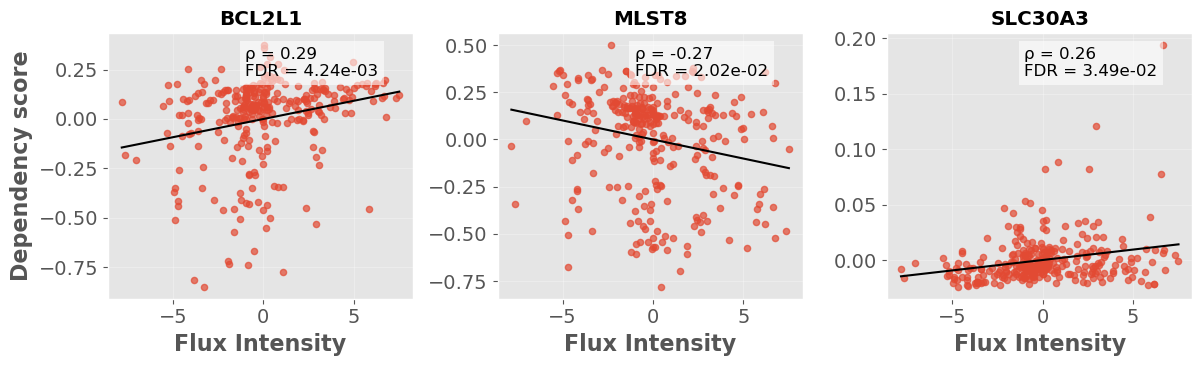

In [10]:
top_flux = res_flux.head(3).copy()

fig, axes = plt.subplots(1, 3, figsize=(12, 4), squeeze=False)
axes = axes.ravel()

for i, (_, row) in enumerate(top_flux.iterrows()):
    gene = row["Gene"]
    rho  = row["rho"]
    p    = row["p"]
    q    = row.get("q", float("nan"))
    n    = int(row["n"])

    # Build plotting frame (Flux residuals vs gene dependency)
    dfp = pd.concat([rX_flux, dependency_df[gene]], axis=1, join="inner").dropna()
    dfp.columns = ["Flux_resid", "Gene_value"]

    sns.regplot(
        x="Flux_resid", y="Gene_value", data=dfp, ax=axes[i],
        ci=None,
        scatter_kws=dict(s=20, alpha=0.7),
        line_kws=dict(lw=1.5, color="black")
    )

    axes[i].set_xlim(*_pad(dfp["Flux_resid"].min(), dfp["Flux_resid"].max()))
    axes[i].set_ylim(*_pad(dfp["Gene_value"].min(), dfp["Gene_value"].max()))

    axes[i].set_title(gene, fontweight='bold')
    axes[i].set_xlabel("Flux Intensity", fontsize=16, fontweight='bold')

    if i == 0:
        axes[i].set_ylabel("Dependency score", fontsize=16, fontweight='bold')
    else:
        axes[i].set_ylabel("")

    axes[i].tick_params(axis='both', which='major', labelsize=14)
    axes[i].grid(True, alpha=0.3)

    axes[i].text(
        0.45, 0.95,
        f"ρ = {rho:.2f}\n"
        f"FDR = {q:.2e}",
        transform=axes[i].transAxes,
        fontsize=12,
        va='top', ha='left',
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none')
    )

# If fewer than 3 genes, remove empty axes
for ax in axes[len(top_flux):]:
    ax.remove()

fig.tight_layout(rect=[0, 0.03, 1, 0.97])
fig.savefig("../data/dependency_analysis/results/proliferation_corr/plots/flux_dependence.png", dpi=300)
plt.show()


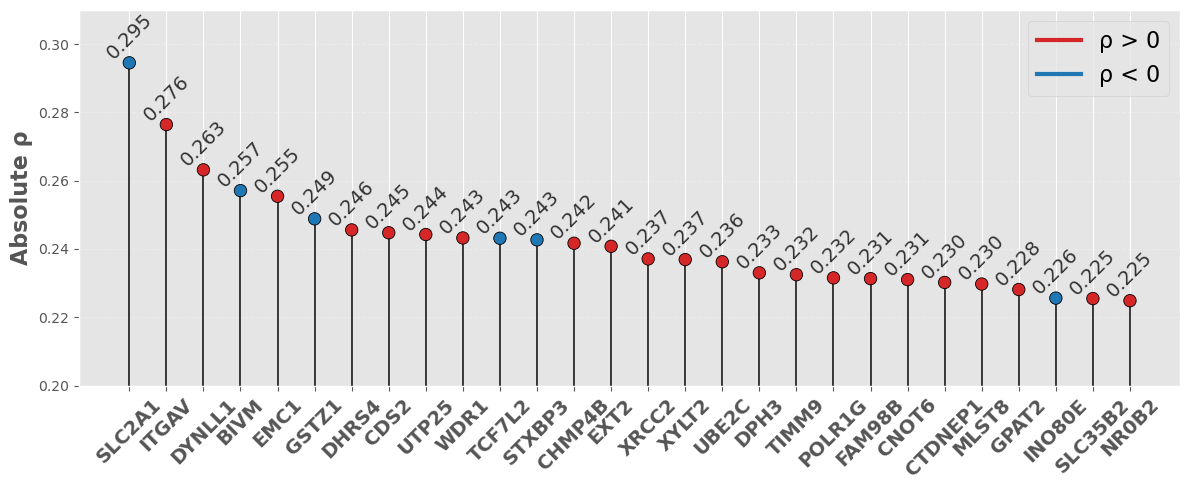

In [11]:
from matplotlib.lines import Line2D

fdr_thr = 0.05
point_size = 80
line_lw = 1.2
xlabel = "Gene"
ylabel = "Absolute ρ"
xrot = 45
outfile = "../data/dependency_analysis/results/proliferation_corr/plots/propensity_lollipop_absrho_vertical_0p2_0p3.png"

sig = res_prop.loc[res_prop["q"] < fdr_thr].copy()
if sig.empty:
    print("Nessun gene significativo a questa soglia FDR.")
else:
    sig["abs_rho"] = sig["rho"].abs()
    sig = sig.sort_values("abs_rho", ascending=False)

    fig, ax = plt.subplots(figsize=(12, 5))

    def color_for_rho(r):
        return "#d62728" if r >= 0 else "#1f77b4"   # rosso = ρ>0, blu = ρ<0

    # coordinates
    x = np.arange(len(sig)) * 1.5
    y = sig["abs_rho"].values

    # vertical line
    for xi, yi, r in zip(x, y, sig["rho"].values):
        ax.vlines(xi, 0, yi, lw=line_lw, color="black", alpha=0.9)

    # dot
    ax.scatter(x, y,
               s=point_size,
               color=[color_for_rho(r) for r in sig["rho"].values],
               edgecolor="black", linewidth=0.6, zorder=3)

    # labels
    ax.set_xticks(x)
    ax.set_xticklabels(sig["Gene"].values,
                       rotation=xrot, ha="center",
                       fontsize=14, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=16, fontweight="bold")

    # ylim
    ax.set_ylim(0.2, 0.31)

    # annotation
    for xi, yi, r_abs in zip(x, y, sig["abs_rho"].values):
        ax.text(xi, yi, f"{r_abs:.3f}",
                ha="center", va="bottom",
                fontsize=14, color="#333", rotation=45)

    ax.grid(axis="y", linestyle="--", alpha=0.25)

    legend_elems = [
        Line2D([0], [0], color="#d62728", lw=3, label="ρ > 0"),
        Line2D([0], [0], color="#1f77b4", lw=3, label="ρ < 0"),
    ]
    ax.legend(handles=legend_elems, loc="upper right", frameon=True, fontsize=16)

    fig.tight_layout()
    fig.savefig(outfile, dpi=600, bbox_inches="tight")
    plt.show()
